200 500


C:\Users\pcobo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pcobo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pcobo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pcobo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[100 100]


C:\Users\pcobo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster 0:
  Total: 41
  Walking: 0
  Running: 41

Cluster 1:
  Total: 100
  Walking: 100
  Running: 0

Cluster 2:
  Total: 59
  Walking: 0
  Running: 59

[ 41 100  59]
Varianza walking: 129.13780997177673
Varianza running: 161.447618014789


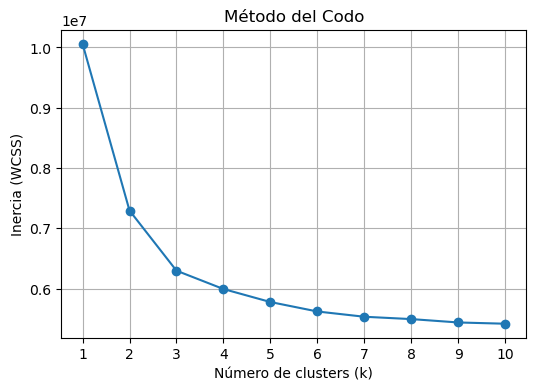

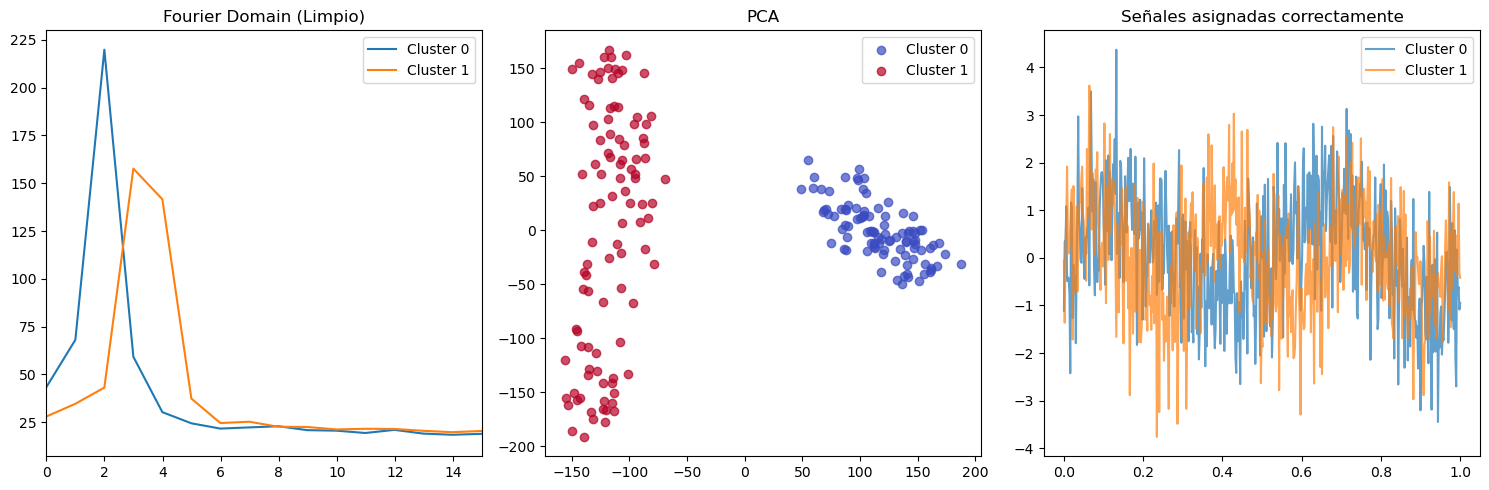

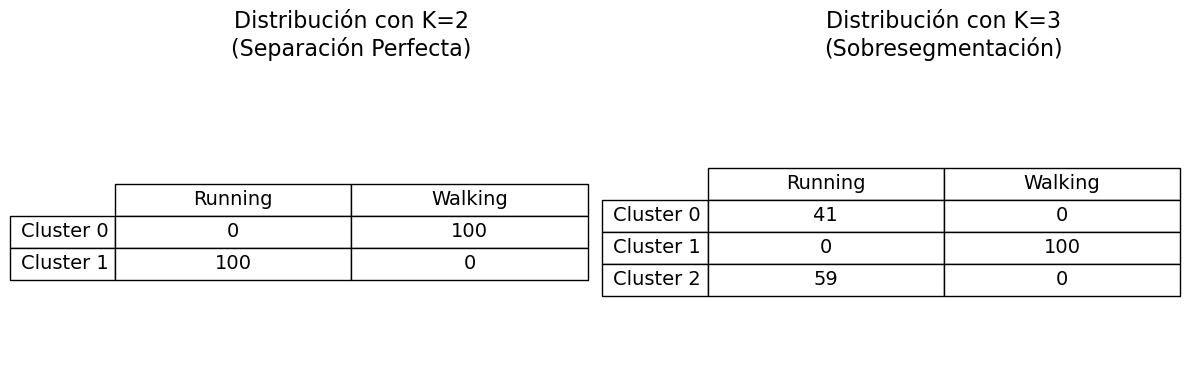


ANÁLISIS PCA - VARIANZA ACUMULADA

Cumsum shape: (200,)
Primeros 10 valores: [0.28750398 0.41729338 0.45857558 0.47541568 0.4860959  0.49528888
 0.50423438 0.51302226 0.5216808  0.53006822]

Componentes necesarios:
  Para 50% varianza: 7 PCs (preservas 50.4%)
  Para 80% varianza: 58 PCs (preservas 80.3%)
  Para 90% varianza: 90 PCs (preservas 90.2%)

✓ Gráfica guardada como 'varianza_acumulada_real.png'


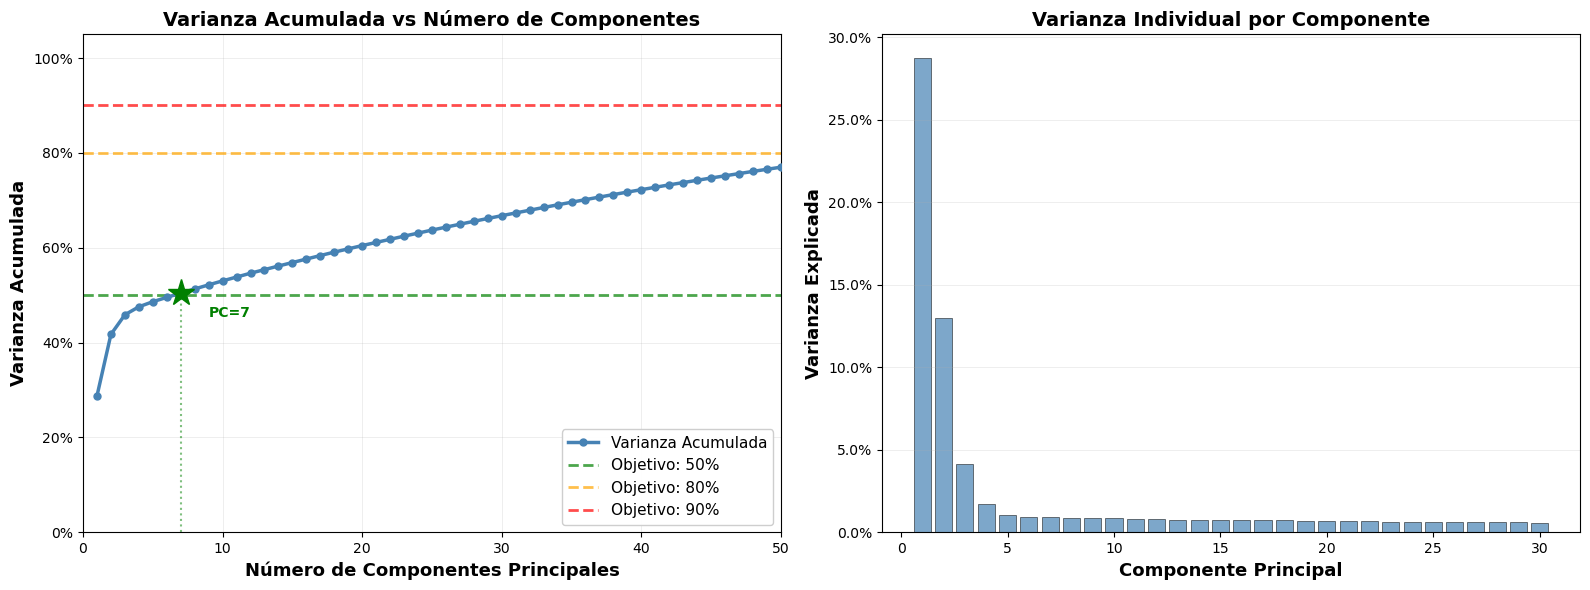


TABLA RESUMEN - VARIANZA ACUMULADA
  PC |  Varianza Individual |   Varianza Acumulada
----------------------------------------------------------------------
   1 |               28.75% |               28.75%
   2 |               12.98% |               41.73%
   3 |                4.13% |               45.86%
   4 |                1.68% |               47.54%
   5 |                1.07% |               48.61%
   6 |                0.92% |               49.53%
  10 |                0.84% |               53.01%
  15 |                0.74% |               56.88%
  20 |                0.68% |               60.45%

PCA FINAL CON n_components ÓPTIMO

Varianza deseada: 90%
n_components necesarios: 90
Varianza real preservada: 90.16%

Matriz original: (200, 251)
Matriz reducida: (200, 90)
Reducción de dimensionalidad: 251 → 90 (factor 2.8x)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Generar Datos
np.random.seed(42)
n_points = 500
t = np.linspace(0, 1, n_points)

walking = np.array([np.sin(2 * np.pi * np.random.uniform(1.5, 2.5) * t) + np.random.normal(0, 1, n_points) for _ in range(100)])
running = np.array([np.sin(2 * np.pi * np.random.uniform(3, 4) * t) + np.random.normal(0, 1, n_points) for _ in range(100)])
X_time = np.vstack((walking, running))
print(len(X_time),len(X_time[0]))
# 2. Transformada de Fourier
X_mag = np.abs(np.fft.rfft(X_time))
freqs = np.fft.rfftfreq(n_points, d=t[1]-t[0])

# 3. K-means SIN StandardScaler
# IMPORTANTE: No escalamos columna por columna para no amplificar el ruido de las frecuencias vacías
kmeans = KMeans(n_clusters=2, random_state=42, n_init=100)
clusters = kmeans.fit_predict(X_mag)


# --- MÉTODO DEL CODO (ELBOW) ---
X_input = X_mag
k_values = range(1, 11)
inertia = []

for k in k_values:
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_elbow.fit(X_mag)
    inertia.append(kmeans_elbow.inertia_)
print(np.bincount(clusters))
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=100)
clusters3 = kmeans3.fit_predict(X_mag)

# Separar etiquetas reales
labels_real = np.array([0]*100 + [1]*100)  # 0=walking, 1=running

# Ver distribución
for cluster_id in range(3):
    idx = np.where(clusters3 == cluster_id)[0]
    reales = labels_real[idx]

    print(f"Cluster {cluster_id}:")
    print("  Total:", len(idx))
    print("  Walking:", np.sum(reales == 0))
    print("  Running:", np.sum(reales == 1))
    print()
print(np.bincount(clusters3))
print("Varianza walking:", np.var(X_mag[:100], axis=0).mean())
print("Varianza running:", np.var(X_mag[100:], axis=0).mean())
# Gráfica
plt.figure(figsize=(6,4))
plt.plot(k_values, inertia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (WCSS)")
plt.xticks(k_values)
plt.grid()

plt.show()
# 4. Visualización
plt.figure(figsize=(15, 5))

# Plot A: Espectro promedio (Ahora verás picos limpios)
plt.subplot(1, 3, 1)
for cluster_id in range(2):
    cluster_mean = X_mag[clusters == cluster_id].mean(axis=0)
    plt.plot(freqs, cluster_mean, label=f'Cluster {cluster_id}')
plt.title("Fourier Domain (Limpio)")
plt.xlim(0, 15)
plt.legend()

#Plot B: PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_mag)

plt.subplot(1, 3, 2)

cmap = plt.cm.coolwarm
n_clusters = len(np.unique(clusters))

for cluster_id in range(n_clusters):
    plt.scatter(
        X_pca[clusters == cluster_id, 0],
        X_pca[clusters == cluster_id, 1],
        label=f'Cluster {cluster_id}',
        color=cmap(cluster_id / (n_clusters - 1)),
        alpha=0.7
    )

plt.title("PCA")
plt.legend()

# Plot C: Tiempo (Corregido para mostrar ejemplos reales de cada cluster)
plt.subplot(1, 3, 3)
idx_0 = np.where(clusters == 0)[0][0]
idx_1 = np.where(clusters == 1)[0][0]
plt.plot(t, X_time[idx_0], label=f'Cluster {clusters[idx_0]}', alpha=0.7)
plt.plot(t, X_time[idx_1], label=f'Cluster {clusters[idx_1]}', alpha=0.7)
plt.title("Señales asignadas correctamente")
plt.legend()

plt.tight_layout()
plt.show()
import pandas as pd

# 5. Crear tablas de contingencia (Cruce de etiquetas reales vs clusters)
def plot_confusion_table(clusters_pred, labels_real, k, ax, title):
    df = pd.DataFrame({'Cluster': clusters_pred, 'Real': labels_real})
    # Mapeamos 0 a Walking y 1 a Running para claridad
    df['Real'] = df['Real'].map({0: 'Walking', 1: 'Running'})

    # Crear tabla cruzada
    ct = pd.crosstab(df['Cluster'], df['Real'])

    # Dibujar la tabla en el plot
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=ct.values,
                     colLabels=ct.columns,
                     rowLabels=[f'Cluster {i}' for i in ct.index],
                     loc='center',
                     cellLoc='center')
    table.set_fontsize(14)
    table.scale(1, 2)
    ax.set_title(title, fontsize=16, pad=20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Tabla para K=2
plot_confusion_table(clusters, labels_real, 2, ax1, "Distribución con K=2\n(Separación Perfecta)")

# Tabla para K=3
plot_confusion_table(clusters3, labels_real, 3, ax2, "Distribución con K=3\n(Sobresegmentación)")

plt.tight_layout()
plt.show()

# ============================================================
# 3. ANÁLISIS PCA - EXPLORACIÓN COMPLETA
# ============================================================
print("\n" + "="*60)
print("ANÁLISIS PCA - VARIANZA ACUMULADA")
print("="*60)

pca_analisis = PCA()  # Sin especificar n_components
pca_analisis.fit(X_mag)  # Entrena con todos los componentes

# Varianza acumulada
cumsum = np.cumsum(pca_analisis.explained_variance_ratio_)

print(f"\nCumsum shape: {cumsum.shape}")
print(f"Primeros 10 valores: {cumsum[:10]}")

# Encontrar puntos de interés
varianza_50 = 0.50
varianza_80 = 0.80
varianza_90 = 0.90

n_comp_50 = np.argmax(cumsum >= varianza_50) + 1
n_comp_80 = np.argmax(cumsum >= varianza_80) + 1
n_comp_90 = np.argmax(cumsum >= varianza_90) + 1

print(f"\nComponentes necesarios:")
print(f"  Para 50% varianza: {n_comp_50} PCs (preservas {cumsum[n_comp_50-1]:.1%})")
print(f"  Para 80% varianza: {n_comp_80} PCs (preservas {cumsum[n_comp_80-1]:.1%})")
print(f"  Para 90% varianza: {n_comp_90} PCs (preservas {cumsum[n_comp_90-1]:.1%})")

# ============================================================
# 4. CREAR GRÁFICA DE VARIANZA ACUMULADA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============ GRÁFICA 1: VARIANZA ACUMULADA ============
n_components_array = np.arange(1, len(cumsum) + 1)

axes[0].plot(n_components_array, cumsum, 'o-', linewidth=2.5, markersize=5, 
            color='steelblue', label='Varianza Acumulada', zorder=3)

# Líneas horizontales de referencia
axes[0].axhline(y=0.50, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo: 50%')
axes[0].axhline(y=0.80, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo: 80%')
axes[0].axhline(y=0.90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo: 90%')

# Marcar puntos importantes
axes[0].plot(n_comp_50, cumsum[n_comp_50-1], 'g*', markersize=20, zorder=4)
axes[0].plot(n_comp_80, cumsum[n_comp_80-1], color='orange', marker='*', markersize=20, zorder=4)
axes[0].plot(n_comp_90, cumsum[n_comp_90-1], 'r*', markersize=20, zorder=4)

# Líneas verticales hacia puntos
axes[0].vlines(n_comp_50, 0, cumsum[n_comp_50-1], colors='green', linestyles='dotted', alpha=0.5)
axes[0].vlines(n_comp_80, 0, cumsum[n_comp_80-1], colors='orange', linestyles='dotted', alpha=0.5)
axes[0].vlines(n_comp_90, 0, cumsum[n_comp_90-1], colors='red', linestyles='dotted', alpha=0.5)

# Anotaciones
axes[0].annotate(f'PC={n_comp_50}', xy=(n_comp_50, cumsum[n_comp_50-1]), 
                xytext=(n_comp_50+2, cumsum[n_comp_50-1]-0.05), fontsize=10, color='green', fontweight='bold')
axes[0].annotate(f'PC={n_comp_80}', xy=(n_comp_80, cumsum[n_comp_80-1]), 
                xytext=(n_comp_80+2, cumsum[n_comp_80-1]-0.05), fontsize=10, color='orange', fontweight='bold')
axes[0].annotate(f'PC={n_comp_90}', xy=(n_comp_90, cumsum[n_comp_90-1]), 
                xytext=(n_comp_90+2, cumsum[n_comp_90-1]-0.05), fontsize=10, color='red', fontweight='bold')

axes[0].set_xlabel('Número de Componentes Principales', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Varianza Acumulada', fontsize=13, fontweight='bold')
axes[0].set_title('Varianza Acumulada vs Número de Componentes', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 50)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
axes[0].legend(loc='lower right', fontsize=11, framealpha=0.95)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# ============ GRÁFICA 2: VARIANZA INDIVIDUAL ============
axes[1].bar(range(1, min(31, len(pca_analisis.explained_variance_ratio_)+1)), 
           pca_analisis.explained_variance_ratio_[:30], 
           color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)

axes[1].set_xlabel('Componente Principal', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Varianza Explicada', fontsize=13, fontweight='bold')
axes[1].set_title('Varianza Individual por Componente', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y', linestyle='-', linewidth=0.5)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.savefig('varianza_acumulada_real.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfica guardada como 'varianza_acumulada_real.png'")

plt.show()

# ============================================================
# 5. TABLA RESUMEN
# ============================================================
print("\n" + "="*70)
print("TABLA RESUMEN - VARIANZA ACUMULADA")
print("="*70)
print(f"{'PC':>4} | {'Varianza Individual':>20} | {'Varianza Acumulada':>20}")
print("-"*70)
for i in [1, 2, 3, 4, 5, 6, 10, 15, 20]:
    if i <= len(pca_analisis.explained_variance_ratio_):
        var_ind = pca_analisis.explained_variance_ratio_[i-1]
        var_acum = cumsum[i-1]
        print(f"{i:4d} | {var_ind:20.2%} | {var_acum:20.2%}")

# ============================================================
# 6. ENTRENAR PCA CON n_components ÓPTIMO
# ============================================================
print("\n" + "="*70)
print("PCA FINAL CON n_components ÓPTIMO")
print("="*70)

varianza_deseada = 0.90
n_components_final = np.argmax(cumsum >= varianza_deseada) + 1

print(f"\nVarianza deseada: {varianza_deseada:.0%}")
print(f"n_components necesarios: {n_components_final}")
print(f"Varianza real preservada: {cumsum[n_components_final-1]:.2%}")

# Entrenar PCA final
pca = PCA(n_components=n_components_final)
X_pca = pca.fit_transform(X_mag)

print(f"\nMatriz original: {X_mag.shape}")
print(f"Matriz reducida: {X_pca.shape}")
print(f"Reducción de dimensionalidad: {X_mag.shape[1]} → {X_pca.shape[1]} (factor {X_mag.shape[1]/X_pca.shape[1]:.1f}x)")